# TEP component extraction via individualized spatiotemporal dipole filters

Single-subject N45 extraction following the current-dipole spatiotemporal-filter approach
of Ahola et al. (2025), built on the same preprocessed data as `TEP_dipole_simple.ipynb`
and organized the same way (numbered sections, one explanation cell above each code cell,
only Section 1 needs editing to move to another subject).

**What this does differently from `TEP_dipole_simple.ipynb`:**

| | `TEP_dipole_simple.ipynb` | this notebook |
|---|---|---|
| dipole per | (group x component) | ONE filter for the whole subject |
| fitted on | each group's own average | the calibration average only |
| latency | peak channel/latency per group | one individualized 3-6 ms window `w_hat` |
| output | group-level dipoles | **single-trial** N45 amplitudes + group summaries |
| fitter | `mne.fit_dipole` | explicit R^2 grid scan over the leadfield |

The point of the change: single-trial TEPs have very low SNR, so a dipole cannot be refit
per trial. Instead one *spatiotemporal filter* -- a fixed cortical position `p_hat`, a fixed
orientation `o_hat`, and a fixed short time window `w_hat` -- is estimated once from the
high-SNR calibration average, then applied unchanged to every single trial. That turns each
trial's 60-channel x 13-sample chunk into one number.

**Pipeline (section numbers below match the source text's own subsection numbering):**

1. Paths, identifiers, and all analysis parameters
2. Load post-stimulus epochs + per-trial provenance table, downsample to 1000 Hz
3. Head model: fsaverage template, ico5 source space (20,484 sources), `standard_1005` sensors
4. Helper functions (dipole scan, window scoring, amplitude extraction)
5. **[2.5.1]** Dipole estimation -- per-time-point scan over T = [38, 50] ms on the calibration average
6. **[2.5.2]** Individualized time-window selection -> `w_hat`, `p_hat`, `o_hat`
7. Diagnostic plots of the scan and the selected window
8. **[2.5.3]** Single-trial amplitude extraction (fixed- and free-orientation), saved to CSV
9. Per-group TEP amplitudes, using the same groups as `TEP_dipole_simple.ipynb`, saved + plotted
10. Save the filter definition itself for reuse

**Aligned to `prime_core`, not to the source text, in five places.** This notebook is meant to
produce numbers comparable with the online PRIME pipeline, so where prime and the paper differ,
prime wins. Each is flagged in the relevant section:

| | prime (followed here) | source text |
|---|---|---|
| Window length | 3-6 **samples** (`WINDOW_SIZE_SAMPLES`) | "3 and 6 ms" |
| Primary amplitude | **free** orientation `||Q||` | fixed orientation `|a|` |
| Resampling | scipy polyphase, Kaiser(5.0) | unspecified |
| Post-stim crops | `post_initial` then `post` (prime.yaml) | unspecified |
| Calibration trials | all surviving trials | "first 100 valid" |

The window-selection formula (Section 4/6) is implemented directly from the published equation
image, not the earlier OCR transcription of it, and its rank convention matches prime's
`DipoleFitter` -- see Section 4.

## 1. Paths, identifiers, and analysis parameters

Everything tunable lives in this one cell. `subject` / `session` are the only lines that need
changing to run this on someone else; the parameters below them are the ones the source text
specifies, kept as named constants so each one can be traced back to the passage it came from.

In [23]:
from pathlib import Path

# ---- subject / session -------------------------------------------------------------
bids_root = Path(r"D:\Linus\Loop\BIDS")
subject = 'Pilot001'
session = 'prime'

# preprocessing.m's outputs (channel rejection, SOUND, SSP-SIR, 3-stage trial rejection
# and average re-referencing have ALL already been applied to this data).
preproc_dir = bids_root / 'derivatives' / 'preprocessing_prime' / f'sub-{subject}' / f'ses-{session}' / 'eeg'
poststim_set = preproc_dir / f'sub-{subject}_ses-{session}_desc-poststim_eeg.set'
trial_info_tsv = preproc_dir / f'sub-{subject}_ses-{session}_desc-preproc_epochs.tsv'

# Same derivatives convention TEP_dipole_simple.ipynb uses.
out_dir = bids_root / 'derivatives' / f'sub-{subject}' / f'ses-{session}'
out_dir.mkdir(parents=True, exist_ok=True)

# ---- [2.5] target interval ----------------------------------------------------------
# "We defined a target time interval of T = [38, 50] ms post-TMS to avoid contamination of
#  early-latency TMS-related artifacts and later-latency sensory-evoked activity."
COMPONENT = 'N45'
T_MS = (38.0, 50.0)

# ---- [2.5.1] which trials build the filter ------------------------------------------
CALIBRATION_QUERY = 'block_label == "calibration"'
N_CALIBRATION_TRIALS = None    # None = ALL calibration trials; set to 100 to match the text

# ---- [2.5.2] window selection -------------------------------------------------------
# Window length is counted in SAMPLES, matching prime_core's DipoleFitter
# (min_window_size=3, max_window_size=6 -> windows of 3, 4, 5 or 6 samples). At the
# 1000 Hz analysis rate one sample IS one millisecond, so this is also the natural
# reading of the source text's "|w| was constrained to be between 3 and 6 ms".
# NOTE: this is a closed-interval span of (n-1) ms for an n-sample window, i.e. a
# 3-sample window spans 2 ms. An earlier version of this notebook enumerated by
# t_end - t_start in [3, 6] ms instead, giving 4-7 sample windows and 34 candidates;
# prime's definition gives 3-6 sample windows and 38 candidates. Matched to prime.
WINDOW_SIZE_SAMPLES = (3, 6)   # (min_window_size, max_window_size), inclusive
ALPHA = 1.5                    # "alpha was set to 1.5" == prime's window_size_exponent
AMPLITUDE_STAT = 'min'         # the ||Q||_w summary that gets rewarded; 'min' per the formula

# How p_hat (an amplitude-weighted MEAN of grid positions, hence generally off-grid) is turned
# back into something with a leadfield:
#   'nearest_source'     -> snap to the closest source in the grid (default; keeps p_hat a real
#                           dipole at a real grid point, and is EXACT whenever the scan picked
#                           the same source at every sample of w_hat, which is the usual case)
#   'weighted_leadfield' -> amplitude-weighted mean of the leadfields themselves
POSITION_MODE = 'nearest_source'

# ---- head model ---------------------------------------------------------------------
# "The leadfield was derived from the fsaverage brain template, comprising 20,484 sources,
#  and mapped to EEG sensors using the standard_1005 electrode locations."
# 20,484 = 10,242 sources/hemisphere = ico5 spacing (NOT the oct6/8,196 that
# TEP_dipole_simple.ipynb used -- that notebook had no reason to match a published count).
SRC_SPACING = 'ico5'
MONTAGE = 'standard_1005'
MINDIST_MM = 0.0               # 0.0 keeps all 20,484 sources; raise to ~5 to drop sources
                               # sitting very close to the inner skull (see Section 3's printout)

# ---- data handling ------------------------------------------------------------------
# preprocessing.m leaves the post-stimulus branch at its native 5000 Hz (only the pre-stimulus
# branch is downsampled); prime works at 1000 Hz (processed_sfreq in prime.yaml). Resample to
# match prime. Set to None to keep the native rate.
TARGET_SFREQ = 1000.0

# Resampling method. 'polyphase_prime' reproduces prime's resample_buffer_polyphase exactly:
# scipy.signal.resample_poly with explicitly-built Kaiser(5.0) FIR taps and reflect padding.
# 'mne' uses epochs.resample()'s own default instead (what this notebook used previously) --
# also a valid anti-aliased decimation, but not sample-identical to prime's.
RESAMPLE_METHOD = 'polyphase_prime'

# Post-stimulus epoch extents, matching prime.yaml. prime crops the raw buffer to
# post_initial [-30, 100] ms, resamples, then narrows to post [1, 100] ms before the dipole
# window is taken. Reproduced here so the data reaching the scan has been through the same
# crops. NOTE: preprocessing.m's post branch starts at -20 ms, so the -30 ms edge is clipped
# to whatever the input actually offers -- reported in the printout below.
POST_INITIAL_MS = (-30.0, 100.0)   # prime: post_initial_tmin / post_initial_tmax
POST_MS = (1.0, 100.0)             # prime: post_tmin / post_tmax

MIN_TRIALS_PER_GROUP = 5       # groups smaller than this are skipped (same rule as _simple)

# ---- fail early and clearly ---------------------------------------------------------
for f in (poststim_set, trial_info_tsv):
    if not f.exists():
        raise FileNotFoundError(
            f"Expected file not found: {f}\nRun preprocessing.m for this subject first.")

print(f"Reading:    {poststim_set}")
print(f"            {trial_info_tsv}")
print(f"Writing to: {out_dir}")
print(f"\nComponent {COMPONENT}: T = [{T_MS[0]:.0f}, {T_MS[1]:.0f}] ms, "
      f"|w| in [{WINDOW_SIZE_SAMPLES[0]}, {WINDOW_SIZE_SAMPLES[1]}] samples, alpha = {ALPHA}")
print(f"Resampling: {RESAMPLE_METHOD} -> {TARGET_SFREQ:.0f} Hz; "
      f"post crops {POST_INITIAL_MS} then {POST_MS} ms (prime.yaml)")

Reading:    D:\Linus\Loop\BIDS\derivatives\preprocessing_prime\sub-Pilot001\ses-prime\eeg\sub-Pilot001_ses-prime_desc-poststim_eeg.set
            D:\Linus\Loop\BIDS\derivatives\preprocessing_prime\sub-Pilot001\ses-prime\eeg\sub-Pilot001_ses-prime_desc-preproc_epochs.tsv
Writing to: D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime

Component N45: T = [38, 50] ms, |w| in [3, 6] samples, alpha = 1.5
Resampling: polyphase_prime -> 1000 Hz; post crops (-30.0, 100.0) then (1.0, 100.0) ms (prime.yaml)


## 2. Load the post-stimulus epochs + per-trial provenance table

Identical to `TEP_dipole_simple.ipynb`'s Section 2 -- `EEG_post` is already epoched, so this
uses MNE's EEGLAB *epochs* reader and attaches the provenance table as metadata -- with two
changes:

- **prime's crop / resample / crop sequence.** The epochs are cropped to prime's
  `post_initial` window, resampled to 1000 Hz with prime's own polyphase resampler
  (`scipy.signal.resample_poly`, explicit Kaiser(5.0) taps, reflect padding -- a verbatim
  reproduction of `prime_core...utils.resampling`), then narrowed to prime's `post` window,
  in that order. Previously this was a bare `epochs.resample()` on the full MATLAB extent;
  both are valid anti-aliased decimations but they are not sample-identical, and the
  difference lands inside the 12 ms analysis window. `RESAMPLE_METHOD = 'mne'` restores the
  old behaviour. One residual mismatch is unavoidable and is printed at runtime:
  preprocessing.m's post branch starts at -20 ms, so prime's -30 ms `post_initial` edge gets
  clipped.
- **No `set_eeg_reference(..., projection=True)` call.** That call only existed in the other
  notebook to satisfy `mne.fit_dipole`'s bookkeeping check; this notebook never calls
  `fit_dipole`, and adding a projector that is never applied makes it ambiguous whether
  `get_data()` returns referenced values or not. Instead, Section 4 mean-centers the data and
  the leadfield **explicitly** across exactly the channel subset being used, which is what an
  average reference *is* and is what the R^2 fit requires. That matters here in a way it didn't
  there: the leadfield rows and the data rows have to be intersected down to their common
  channels first, and an average reference computed over the full 60-channel set is no longer
  an average reference over that intersection.

In [24]:
import mne
import numpy as np
import pandas as pd

epochs = mne.io.read_epochs_eeglab(str(poststim_set))

trial_info = pd.read_csv(trial_info_tsv, sep='\t')
# Empty CSV cells (e.g. "condition" for baseline/calibration/evaluation trials) come back as
# NaN, not the empty string they actually were -- restore that so the query strings below
# behave the same regardless of which case they are matching against.
trial_info = trial_info.fillna('')

# preprocessing.m guarantees EEG_pre / EEG_post / EMG / all_trial_info stay trial-for-trial
# aligned all the way through (its own Section 16 consistency check), so trial_info.iloc[i]
# describes epochs[i]. Everything below leans on this.
assert len(epochs) == len(trial_info), (
    f"epochs has {len(epochs)} trials but trial_info has {len(trial_info)} rows -- these must "
    "match. Something is inconsistent between the .set file and the .tsv file.")

epochs.metadata = trial_info.reset_index(drop=True)

# The .set file's own channel positions are not reliably carried over by MNE's EEGLAB reader;
# attach the template layout the source text specifies instead.
epochs.set_montage(mne.channels.make_standard_montage(MONTAGE), on_missing='warn')

sfreq_native = epochs.info['sfreq']

# --- prime's post-stimulus crop / resample / crop sequence (prime.yaml) ---------------
# 1) crop to post_initial, 2) resample, 3) crop to post. Done in this order so the
#    resampler sees the same extent prime's does.
pi_lo = max(POST_INITIAL_MS[0] / 1000.0, epochs.tmin)
pi_hi = min(POST_INITIAL_MS[1] / 1000.0, epochs.tmax)
if pi_lo > POST_INITIAL_MS[0] / 1000.0 + 1e-9:
    print(f"NOTE: post_initial starts at {POST_INITIAL_MS[0]:.0f} ms in prime, but this input "
          f"only begins at {epochs.tmin*1000:.0f} ms -- clipped to {pi_lo*1000:.0f} ms.")
epochs.crop(pi_lo, pi_hi, include_tmax=True)

if TARGET_SFREQ is not None and abs(sfreq_native - TARGET_SFREQ) > 1e-6:
    if RESAMPLE_METHOD == 'polyphase_prime':
        # Verbatim reproduction of prime_core.preprocessing.utils.resampling.
        from fractions import Fraction
        import math
        from scipy.signal import firwin, resample_poly

        ratio = Fraction(str(TARGET_SFREQ)) / Fraction(str(sfreq_native))
        up, down = ratio.numerator, ratio.denominator
        g = math.gcd(up, down)
        up, down = up // g, down // g
        max_rate = max(up, down)
        taps = firwin(2 * (10 * max_rate) + 1, 1.0 / max_rate, window=("kaiser", 5.0))

        data = epochs.get_data(copy=True)                       # (n_trials, n_ch, n_times)
        data = resample_poly(data, up=up, down=down, axis=2,
                             window=taps.astype(data.dtype), padtype='reflect')
        info_rs = epochs.info.copy()
        with info_rs._unlock():
            info_rs['sfreq'] = TARGET_SFREQ
        epochs = mne.EpochsArray(data, info_rs, events=epochs.events, tmin=epochs.tmin,
                                 metadata=epochs.metadata, verbose=False)
        print(f"Resampled {sfreq_native:.0f} -> {TARGET_SFREQ:.0f} Hz "
              f"(prime polyphase: up={up}, down={down}, Kaiser(5.0), reflect padding).")
    elif RESAMPLE_METHOD == 'mne':
        epochs.resample(TARGET_SFREQ)
        print(f"Resampled {sfreq_native:.0f} -> {epochs.info['sfreq']:.0f} Hz (MNE default).")
    else:
        raise ValueError(f"Unknown RESAMPLE_METHOD: {RESAMPLE_METHOD!r}")

# 3) narrow to prime's post window
epochs.crop(max(POST_MS[0] / 1000.0, epochs.tmin),
            min(POST_MS[1] / 1000.0, epochs.tmax), include_tmax=True)
print(f"Cropped to prime's post window: {epochs.tmin*1000:.0f} to {epochs.tmax*1000:.0f} ms.")

sfreq = epochs.info['sfreq']
print(f"Loaded {len(epochs)} post-stimulus trials, {len(epochs.ch_names)} channels, "
      f"{sfreq:.0f} Hz, {epochs.tmin*1000:.0f} to {epochs.tmax*1000:.0f} ms.")

# Does the target interval actually fit inside the epoch, and how many samples does it get?
t_ms = epochs.times * 1000
in_T = (t_ms >= T_MS[0] - 1e-9) & (t_ms <= T_MS[1] + 1e-9)
if not in_T.any():
    raise ValueError(f"T = {T_MS} ms lies outside the epoch "
                     f"({t_ms[0]:.1f} to {t_ms[-1]:.1f} ms).")
print(f"Target interval T = [{T_MS[0]:.0f}, {T_MS[1]:.0f}] ms -> {in_T.sum()} samples "
      f"({t_ms[in_T][0]:.1f} ... {t_ms[in_T][-1]:.1f} ms).")

n_cal_available = len(epochs[CALIBRATION_QUERY])
print(f"Calibration trials available: {n_cal_available}"
      + (f" (using all)" if N_CALIBRATION_TRIALS is None
         else f" (using first {N_CALIBRATION_TRIALS})"))

Extracting parameters from D:\Linus\Loop\BIDS\derivatives\preprocessing_prime\sub-Pilot001\ses-prime\eeg\sub-Pilot001_ses-prime_desc-poststim_eeg.set...
Not setting metadata
756 matching events found
No baseline correction applied
0 projection items activated
Ready.
Adding metadata with 26 columns
NOTE: post_initial starts at -30 ms in prime, but this input only begins at 1 ms -- clipped to 1 ms.
Cropped to prime's post window: 1 to 100 ms.
Loaded 756 post-stimulus trials, 60 channels, 1000 Hz, 1 to 100 ms.
Target interval T = [38, 50] ms -> 13 samples (38.0 ... 50.0 ms).
Calibration trials available: 119 (using all)


C:\Users\linus\AppData\Local\Temp\ipykernel_18560\3370736833.py:5: RuntimeWarning: Estimated head radius (11.7 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  epochs = mne.io.read_epochs_eeglab(str(poststim_set))


## 3. Head model and leadfield

Built once and reused for every scan, every trial and every group below. This is the slow cell
(fetching/building fsaverage + BEM + forward solution); everything after it is fast.

Three things differ from `TEP_dipole_simple.ipynb`'s Section 3:

- **`ico5`, not `oct6`.** The source text pins the leadfield at 20,484 sources, which is ico5
  (10,242/hemisphere). oct6 would give 8,196.
- **`mindist = 0` by default,** so no sources get dropped and the count actually lands on
  20,484. The printout below reports the real number after the forward solution is built --
  if it comes back short, MNE excluded sources for being too close to the inner skull, and
  `MINDIST_MM` is the knob for that.
- **No noise covariance.** The ad-hoc 0.2 uV covariance in the other notebook existed only
  because `mne.fit_dipole` requires one for whitening. The estimator here is the plain
  least-squares / R^2 one written out in the source text (`Q = pinv(L_p) m`, maximize R^2),
  which has no whitening step, so there is nothing for a covariance to do.

The leadfield is pulled out as a plain `(n_channels, n_sources, 3)` array, with rows
intersected against the epochs' channels **by name and in a known order**, so the numpy code
downstream can never silently mismatch a leadfield row to the wrong electrode.

In [25]:
import os

fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
subjects_dir = os.path.dirname(fs_dir)
trans = 'fsaverage'   # magic string: use fsaverage's own built-in template transform

# fsaverage ships some source spaces prebuilt; use one if present, otherwise build and cache it.
_candidates = [os.path.join(fs_dir, 'bem', f'fsaverage-{SRC_SPACING}-src.fif'),
               os.path.join(fs_dir, 'bem', 'fsaverage-ico-5-src.fif')]
src = None
for _fname in _candidates:
    if os.path.isfile(_fname):
        src = mne.read_source_spaces(_fname)
        print(f"Using cached source space: {_fname}")
        break
if src is None:
    src = mne.setup_source_space(subject='fsaverage', spacing=SRC_SPACING,
                                 subjects_dir=subjects_dir, add_dist=False)
    mne.write_source_spaces(_candidates[0], src, overwrite=True)
    print(f"Built and cached source space: {_candidates[0]}")

bem = mne.read_bem_solution(os.path.join(fs_dir, 'bem',
                                         'fsaverage-5120-5120-5120-bem-sol.fif'))

fwd = mne.make_forward_solution(epochs.info, trans=trans, src=src, bem=bem,
                                meg=False, eeg=True, mindist=MINDIST_MM, n_jobs=1)
# Cartesian free orientation: sol['data'] columns run [src0_x, src0_y, src0_z, src1_x, ...],
# and .ori vectors below are therefore interpretable directly in head coordinates.
fwd = mne.convert_forward_solution(fwd, surf_ori=False, force_fixed=False)

# --- intersect leadfield rows with epoch channels, by name, in a fixed order ----------
fwd_ch_names = list(fwd['sol']['row_names'])
epoch_ch_set = set(epochs.ch_names)
ch_used = [ch for ch in fwd_ch_names if ch in epoch_ch_set]
if len(ch_used) < 20:
    raise RuntimeError(f"Only {len(ch_used)} channels are common to the forward solution and "
                       "the epochs -- montage/channel naming is probably mismatched.")

row_idx = [fwd_ch_names.index(ch) for ch in ch_used]        # into the leadfield
data_idx = np.array([epochs.ch_names.index(ch) for ch in ch_used])  # into epochs.get_data()

leadfield = fwd['sol']['data'][row_idx].reshape(len(ch_used), -1, 3)  # (n_ch, n_src, 3)
src_pos = fwd['source_rr']                                            # (n_src, 3), head coords, m

n_ch, n_src, _ = leadfield.shape
print(f"\nLeadfield: {n_ch} channels x {n_src} sources x 3 orientations "
      f"({leadfield.nbytes/1e6:.0f} MB)")
if n_src != 20484:
    print(f"  NOTE: {n_src} sources, not the 20,484 the source text reports. "
          f"{'Lower MINDIST_MM' if n_src < 20484 else 'Check SRC_SPACING'} to match.")
if len(ch_used) != len(epochs.ch_names):
    dropped = sorted(set(epochs.ch_names) - set(ch_used))
    print(f"  NOTE: {len(dropped)} epoch channel(s) have no leadfield row and are excluded "
          f"from every fit below: {dropped}")

0 files missing from root.txt in C:\Users\linus\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\linus\mne_data\MNE-fsaverage-data\fsaverage
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Using cached source space: C:\Users\linus\mne_data\MNE-fsaverage-data\fsaverage\bem\fsaverage-ico-5-src.fif
Loading surfaces...

Loading the solution matrix...

Three-layer model surfaces loaded.
Loaded linear collocation BEM solution from C:\Users\linus\mne_data\MNE-fsaverage-data\fsaverage\bem\fsaverage-5120-5120-5120-bem-sol.fif
Source space          : <SourceSpaces: [<surface (lh), n_vertices=163842, n_used=10242>, <surface (rh), n_vertices=163842, n_used=10242>] MRI (surface RAS) coords, subject 'fsaverage', ~21.9 MiB>
MRI -> head transform : C:\Users\linus\AppData\Roaming\Python\Python311\site-packages\mne\data\fsaverage\fsaverage-trans.fif
Measurement data      : instance of Info
Conductor model   : instance of Cond

## 4. Helper functions

The whole method, written out once so Sections 5-9 are just calls. Four pieces:

**`_center`** -- mean-centers across the channel axis. Applied to both the data and the
leadfield so that the fit is carried out in a proper average reference over exactly the
`ch_used` subset (Section 2 explains why this is done here rather than via an MNE projector).

**`r2`** -- `1 - SS_res/SS_tot` with `SS_tot` about the mean of the measurement, i.e. exactly
`sklearn.metrics.r2_score(y_measured, y_predicted)`, matching the reference implementation in
`oskari_util_funcs.py`. Written in numpy so this notebook does not need sklearn.

**`scan_dipoles`** -- **[2.5.1]**. For each time point `t` it computes, at *every* source
position `p` in the grid, the single-dipole least-squares moment
`Q = pinv(L_p) m_t = argmin_Q ||m_t - L_p Q||^2`, and keeps the position whose predicted
topography `L_p Q` maximizes `R^2(m_t, L_p Q)`. That is literally
`{Q_hat_t, p_hat_t} = argmax_p R^2(m_t, L_p Q_t)` from the text. Because the per-source
pseudoinverse depends only on the (fixed) leadfield, it is precomputed once
(`precompute_pinv`) and reused across every time point.

**`score_windows` / `select_window`** -- **[2.5.2]**. Enumerates every sub-window of `T` whose
LENGTH IN SAMPLES falls in `WINDOW_SIZE_SAMPLES = (3, 6)`, and scores it. Per the source
equation (read directly from the published formula image, not the earlier OCR transcription
of it):

```
                    ra(|w|)^alpha
w_hat = argmax_w  -------------------------------------------------
                  ra(dp_w) + ra(dphi_w) + rd(min_t ||Q||_t)
```

i.e. a **fraction**: `ra(|w|)^alpha` alone in the numerator, and the sum of the three
stability/amplitude terms in the denominator -- not, as an earlier reading of a garbled OCR
transcription had it, all four terms multiplied together. `|w|` is the window length **in
samples** (prime ranks the sample count directly; ranking by sample count and by ms span is
equivalent at a uniform rate), `dp_w` and `dphi_w` are the mean positional and angular deviances
of the per-sample dipoles from their own mean within `w`, `ra(.)` is ascending rank and `rd(.)`
descending, and `alpha = 1.5` (= prime's `window_size_exponent`).

With this structure the ranks do not need any sign-flipping to match the prose ("penalizing
deviations in dipole position and orientation while rewarding high signal amplitude") -- being
in the *denominator* already does the penalizing/rewarding correctly on their own terms:

- `ra(dp_w)`, `ra(dphi_w)` -- high positional/angular deviance ranks high (close to 1),
  enlarging the denominator, which *shrinks* the score. High deviance is penalized.
- `rd(min||Q||_w)` -- high minimum amplitude ranks *low* (close to 0) under a descending rank,
  shrinking the denominator, which *grows* the score. High amplitude is rewarded.
- `ra(|w|)^alpha` in the numerator rewards longer windows, as the constrained `[3, 6]` ms range
  and `alpha = 1.5` both specify directly.

**Ranks are raw, 1..N (ties averaged) -- the same convention `pandas.Series.rank(method='average')`
uses -- not normalized to `[0, 1]`.** This matches `prime_core`'s own `DipoleFitter`
(`determine_optimal_index_range`), a working reference implementation of this exact method found
in this project's own codebase, whose scoring is the identical fraction above, computed with raw
pandas ranks. An earlier version of this notebook normalized ranks to `[0, 1]` and floored the
denominator at a small epsilon to avoid dividing by zero -- reasonable-looking, but it introduces
a real instability that raw ranks do not have: a normalized rank can be *exactly* 0 (the single
best candidate on an axis), so a window that happens to be simultaneously near-best on position,
orientation, *and* amplitude can drive the denominator to genuinely ~0, and dividing by the
epsilon floor then produces an enormous, numerically unstable score that wins outright regardless
of duration -- not because the formula weighed duration against stability and stability won, but
as a floating-point artifact of how close to the floor the denominator happened to land. Raw
ranks never go below 1 (nobody can rank better than 1st), so the denominator can never fall below
3, no epsilon guard is needed, and scores stay in a sane, bounded range for every candidate.

**`extract_amplitudes`** -- **[2.5.3]**. Applies the finished filter to any set of
topographies (single trials in Section 8, group averages in Section 9). For each input it
searches `t` over `w_hat` only, at the fixed position `p_hat`, and returns:

- **free orientation (PRIMARY)**: `||Q_t*||` where `Q_t = pinv(L_p_hat) m_t`, at the `t`
  maximizing `R^2`. This is the headline amplitude, because it is the one prime actually
  uses: every call site in `prime_core` invokes `DipoleFitter.fit_trial` with its default
  `orientation='free'`, and the `'fixed'` branch is never exercised anywhere in that codebase.
- *fixed orientation (secondary)*: scalar `a_t` solving `m_t = a_t L_p_hat o_hat` in least
  squares, scored by `R^2`, reported as `|a_t*|` at the best `t` ("the estimated scalar
  amplitude can be negative due to noise or polarity reversal, we used the absolute
  amplitude"). Kept for comparison with the source text, which treats this one as primary.

The free-orientation model has 3 free parameters against the fixed model's 1, so its `R^2` is
*necessarily* >= the fixed model's at every time point, and therefore also after the argmax.
They are not competing estimates of the same quantity -- the fixed model is the stricter,
lower-variance filter (orientation is not allowed to chase noise), the free model the more
permissive one. Both are computed and saved for every trial; only which one is treated as the
headline number differs, and that choice is now aligned with prime rather than with the paper.

**The same is NOT true of the amplitudes**, and it is worth knowing why before the numbers look
surprising. `amp_fixed` can exceed `amp_free` on a given trial, for two reasons:

1. `a_t = (l . m_t)/(l . l)` divides by `||l||^2`. If `o_hat` happens to point along a
   direction the sensors see weakly, `l` is small and `a_t` is correspondingly inflated --
   fitting a weakly-visible orientation *requires* a big moment. `||Q||` carries no such
   normalization.
2. The two models each take their own argmax over `w_hat`, so they frequently land on
   different samples entirely.

On this dataset that happens on roughly one trial in six. It is expected behaviour, not a
symptom of a broken filter. The two columns should be treated as two different measurements
and analyzed separately -- not differenced, and not used interchangeably.

In [26]:
import numpy as np
import pandas as pd


# ---- shared numerics ----------------------------------------------------------------
def _center(x, axis=0):
    """Mean-center along `axis` -- i.e. put into average reference across channels."""
    return x - x.mean(axis=axis, keepdims=True)


def r2(y_true, y_pred, axis=-1):
    """
    Coefficient of determination, identical to sklearn.metrics.r2_score for the 1-D case
    but vectorized over leading axes: 1 - SS_res/SS_tot, SS_tot about mean(y_true).
    """
    ss_res = np.sum((y_true - y_pred) ** 2, axis=axis)
    ss_tot = np.sum((y_true - y_true.mean(axis=axis, keepdims=True)) ** 2, axis=axis)
    with np.errstate(divide='ignore', invalid='ignore'):
        out = 1.0 - ss_res / ss_tot
    return np.where(ss_tot > 0, out, -np.inf)


def precompute_pinv(L):
    """
    Per-source Moore-Penrose pseudoinverse of the leadfield. Depends only on the (fixed)
    leadfield, so it is computed once and reused for every time point / trial / group.

    L       : (n_ch, n_src, 3), already channel-centered
    returns : (n_src, 3, n_ch) such that Q_s = out[s] @ m
    """
    Lt = np.ascontiguousarray(L.transpose(1, 0, 2))          # (n_src, n_ch, 3)
    gram = np.matmul(Lt.transpose(0, 2, 1), Lt)              # (n_src, 3, 3) = L_s^T L_s
    gram_inv = np.linalg.pinv(gram)                          # robust to rank-deficient sources
    return np.matmul(gram_inv, Lt.transpose(0, 2, 1))        # (n_src, 3, n_ch)


# ---- [2.5.1] dipole estimation ------------------------------------------------------
def scan_dipoles(data, Lt, pinv_L, src_pos):
    """
    {Q_hat_t, p_hat_t} = argmax_p R^2( m_t , L_p Q_t ),  Q_t = pinv(L_p) m_t

    data   : (n_ch, n_times), channel-centered
    Lt     : (n_src, n_ch, 3), the channel-centered leadfield transposed
    pinv_L : (n_src, 3, n_ch) from precompute_pinv
    Returns a dict of per-time-point arrays.
    """
    n_times = data.shape[1]
    out = dict(src_idx=np.zeros(n_times, dtype=int),
               pos=np.zeros((n_times, 3)),
               moment=np.zeros((n_times, 3)),
               amplitude=np.zeros(n_times),
               r2=np.zeros(n_times))

    for ti in range(n_times):
        m = data[:, ti]                                      # (n_ch,)
        q = pinv_L @ m                                       # (n_src, 3)
        pred = np.matmul(Lt, q[:, :, None])[:, :, 0]         # (n_src, n_ch)
        r2_all = r2(np.broadcast_to(m, pred.shape), pred, axis=1)

        s = int(np.argmax(r2_all))
        out['src_idx'][ti] = s
        out['pos'][ti] = src_pos[s]
        out['moment'][ti] = q[s]
        out['amplitude'][ti] = np.linalg.norm(q[s])
        out['r2'][ti] = r2_all[s]
    return out


# ---- [2.5.2] individualized time-window selection ------------------------------------
def _rank_ascending(x):
    """
    Raw ascending rank, 1..N, ties averaged -- i.e. exactly
    `pandas.Series(x).rank(method='average', ascending=True)`, matching prime_core's
    DipoleFitter (see Section 4's markdown for why this replaced an earlier [0,1]-normalized
    version). Smallest raw value -> rank 1, largest -> rank N.
    """
    return pd.Series(x, dtype=float).rank(method='average', ascending=True).to_numpy()


def _rank_descending(x):
    """Raw descending rank, 1..N, ties averaged. Largest raw value -> rank 1, smallest -> rank N."""
    return pd.Series(x, dtype=float).rank(method='average', ascending=False).to_numpy()


def score_windows(durations, pos_dev, ang_dev, amp, alpha):
    """
    score(w) = size_rank^alpha / (pos_rank + ang_rank + amp_rank_descending)

    Straight from the published equation (a fraction, numerator over denominator) -- see
    Section 4's markdown -- computed with raw ranks (1..N), matching prime_core's
    DipoleFitter.determine_optimal_index_range exactly. Raw ranks never fall below 1, so the
    denominator can never fall below 3 (three terms, each >= 1): no epsilon guard is needed,
    and no candidate can produce a numerically unstable, artificially huge score the way a
    near-zero normalized denominator could.
    """
    numerator = _rank_ascending(durations) ** alpha
    denominator = _rank_ascending(pos_dev) + _rank_ascending(ang_dev) + _rank_descending(amp)
    return numerator / denominator


def select_window(scan, times_ms, window_size_samples, alpha, amplitude_stat='min'):
    """
    Enumerate every sub-window of the scanned interval whose LENGTH IN SAMPLES falls in
    `window_size_samples`, score it, and return the best one plus the amplitude-weighted
    p_hat / o_hat over it.

    Window length is a sample count, matching prime_core's determine_optimal_index_range:

        for window_size in range(min_window_size, max_window_size + 1):
            for start in range(n_indices - window_size + 1):
                end = start + window_size          # half-open, so `window_size` samples

    Here (i, j) are INCLUSIVE indices, so an n-sample window is (i, i + n - 1) and spans
    (n - 1) ms at 1000 Hz.
    """
    size_min, size_max = window_size_samples
    n = len(times_ms)

    cand = []
    for size in range(int(size_min), int(size_max) + 1):
        for i in range(n - size + 1):
            cand.append((i, i + size - 1))         # inclusive end
    if not cand:
        raise ValueError(
            f"No window of {size_min}-{size_max} samples fits inside the "
            f"{n}-sample interval [{times_ms[0]:.1f}, {times_ms[-1]:.1f}] ms.")

    unit_moment = scan['moment'] / np.maximum(
        np.linalg.norm(scan['moment'], axis=1, keepdims=True), 1e-30)

    # prime ranks by `size` (the sample count). Ranking by sample count and by ms span is
    # equivalent here (span = size - 1 at a uniform rate), but the sample count is what
    # prime literally feeds to .rank(), so use it.
    sizes = np.array([j - i + 1 for i, j in cand], dtype=float)
    durations = np.array([times_ms[j] - times_ms[i] for i, j in cand])
    pos_dev = np.zeros(len(cand))
    ang_dev = np.zeros(len(cand))
    amp_stat = np.zeros(len(cand))

    for k, (i, j) in enumerate(cand):
        pos_w = scan['pos'][i:j + 1]
        ori_w = unit_moment[i:j + 1]
        amp_w = scan['amplitude'][i:j + 1]

        # mean positional deviance from the window's own mean position, in mm
        pos_dev[k] = np.mean(np.linalg.norm(pos_w - pos_w.mean(axis=0), axis=1)) * 1000

        # mean angular deviance from the window's own mean orientation, in degrees.
        # No +/- folding: within a stable 3-6 ms window a polarity flip is genuine
        # instability and SHOULD be penalized.
        mean_ori = ori_w.mean(axis=0)
        nrm = np.linalg.norm(mean_ori)
        mean_ori = mean_ori / nrm if nrm > 1e-12 else ori_w[0]
        ang_dev[k] = np.mean(np.degrees(np.arccos(np.clip(ori_w @ mean_ori, -1.0, 1.0))))

        amp_stat[k] = amp_w.min() if amplitude_stat == 'min' else amp_w.mean()

    scores = score_windows(sizes, pos_dev, ang_dev, amp_stat, alpha)
    best = int(np.argmax(scores))
    i, j = cand[best]

    # p_hat / o_hat = amplitude-weighted averages over w_hat.
    amp_w = scan['amplitude'][i:j + 1]
    p_bar = np.average(scan['pos'][i:j + 1], axis=0, weights=amp_w)
    # sum_t amp_t * (Q_t/amp_t) == sum_t Q_t, so the amplitude-weighted mean orientation is
    # just the normalized sum of moments.
    o_raw = scan['moment'][i:j + 1].sum(axis=0)
    o_hat = o_raw / np.linalg.norm(o_raw)

    table = pd.DataFrame(dict(
        start_ms=[times_ms[a] for a, _ in cand], end_ms=[times_ms[b] for _, b in cand],
        n_samples=sizes.astype(int), duration_ms=durations,
        pos_dev_mm=pos_dev, ang_dev_deg=ang_dev,
        amp_stat_nAm=amp_stat * 1e9, score=scores)).sort_values('score', ascending=False)

    return dict(start_idx=i, end_idx=j,
                start_ms=float(times_ms[i]), end_ms=float(times_ms[j]),
                n_samples=int(sizes[best]), duration_ms=float(durations[best]),
                score=float(scores[best]),
                p_bar=p_bar, o_hat=o_hat,
                pos_dev_mm=float(pos_dev[best]), ang_dev_deg=float(ang_dev[best]),
                n_candidates=len(cand), candidates=table)


# ---- [2.5.3] amplitude extraction ----------------------------------------------------
def extract_amplitudes(data, l_fixed, L_p):
    """
    Apply the finished spatiotemporal filter to a stack of topographies.

    data    : (n_items, n_ch, n_times) restricted to w_hat, channel-centered
    l_fixed : (n_ch,)     = L_p_hat @ o_hat, channel-centered   -> fixed-orientation model
    L_p     : (n_ch, 3)   = leadfield at p_hat, channel-centered -> free-orientation model

    Returns a dict of (n_items,) arrays. `*_signed` keeps the fixed model's sign so polarity
    reversals stay inspectable; `amp_fixed` is its absolute value, per the source text.
    """
    # --- fixed orientation: a_t = (l.m_t)/(l.l), scored by R^2, argmax over t in w_hat ---
    denom = float(l_fixed @ l_fixed)
    a = np.einsum('c,ict->it', l_fixed, data) / denom              # (n_items, n_times)
    pred_fixed = a[:, None, :] * l_fixed[None, :, None]            # (n_items, n_ch, n_times)
    r2_fixed = r2(data, pred_fixed, axis=1)                        # (n_items, n_times)
    tf = np.argmax(r2_fixed, axis=1)
    idx = np.arange(data.shape[0])
    a_best = a[idx, tf]

    # --- free orientation: Q_t = pinv(L_p) m_t, scored by R^2, argmax over t in w_hat ---
    pinv_Lp = np.linalg.pinv(L_p)                                  # (3, n_ch)
    Q = np.einsum('dc,ict->idt', pinv_Lp, data)                    # (n_items, 3, n_times)
    pred_free = np.einsum('cd,idt->ict', L_p, Q)
    r2_free = r2(data, pred_free, axis=1)
    tr = np.argmax(r2_free, axis=1)
    Q_best = Q[idx, :, tr]                                         # (n_items, 3)

    return dict(amp_fixed=np.abs(a_best), amp_fixed_signed=a_best,
                r2_fixed=r2_fixed[idx, tf], t_idx_fixed=tf,
                amp_free=np.linalg.norm(Q_best, axis=1), moment_free=Q_best,
                r2_free=r2_free[idx, tr], t_idx_free=tr)


print("Helper functions defined.")

Helper functions defined.


## 5. [2.5.1] Dipole estimation on the calibration average

Average the calibration trials into one evoked response, restrict to `T = [38, 50] ms`, and
run the grid scan at every sample in that interval: at each time point, fit a free-orientation
single dipole at every one of the ~20,484 candidate cortical positions and keep whichever
position explains that instant's scalp topography best.

The result is a short trajectory -- one position, one moment vector, one `R^2` per sample --
which is what Section 6 then searches for a stable stretch. Watch the `src` column in the
printout: a run of identical source indices is exactly the "stable, high-amplitude" behaviour
the window selection is looking for, and a column that changes at every sample means the
scan is chasing noise rather than tracking one generator.

In [27]:
# Calibration average -> the one high-SNR topography the whole filter is derived from.
cal_epochs = epochs[CALIBRATION_QUERY]
if N_CALIBRATION_TRIALS is not None:
    cal_epochs = cal_epochs[:N_CALIBRATION_TRIALS]
n_cal = len(cal_epochs)
if n_cal < MIN_TRIALS_PER_GROUP:
    raise RuntimeError(f"Only {n_cal} calibration trial(s) -- cannot build a filter from that.")

cal_evoked = cal_epochs.average()

# Indices of T within the epoch, and the corresponding channel-centered data.
T_idx = np.where(in_T)[0]
times_T_ms = epochs.times[T_idx] * 1000

cal_data_T = _center(cal_evoked.data[data_idx][:, T_idx], axis=0)   # (n_ch, n_T)
Lc = _center(leadfield, axis=0)                                    # average-reference leadfield
Lt = np.ascontiguousarray(Lc.transpose(1, 0, 2))                   # (n_src, n_ch, 3)
pinv_L = precompute_pinv(Lc)

scan = scan_dipoles(cal_data_T, Lt, pinv_L, src_pos)

print(f"Scanned {len(T_idx)} time points x {n_src} sources, "
      f"built from {n_cal} calibration trials.\n")
print(f"{'t (ms)':>8}{'src':>9}{'|Q| (nAm)':>12}{'R2':>8}   position (mm, head coords)")
for k, t in enumerate(times_T_ms):
    p = scan['pos'][k] * 1000
    print(f"{t:8.1f}{scan['src_idx'][k]:9d}{scan['amplitude'][k]*1e9:12.2f}"
          f"{scan['r2'][k]:8.3f}   [{p[0]:6.1f} {p[1]:6.1f} {p[2]:6.1f}]")

n_distinct = len(np.unique(scan['src_idx']))
print(f"\n{n_distinct} distinct source position(s) selected across T "
      f"({len(T_idx)} samples).")

Scanned 13 time points x 20484 sources, built from 119 calibration trials.

  t (ms)      src   |Q| (nAm)      R2   position (mm, head coords)
    38.0    19040        8.06   0.461   [  26.5  -19.9  105.9]
    39.0    11290       10.63   0.631   [  11.1   -7.0  116.7]
    40.0    17735       11.73   0.645   [   8.1   -3.0  117.5]
    41.0    13210       11.21   0.646   [  10.6   -9.5  115.2]
    42.0    16248       10.64   0.585   [  19.0  -48.2   85.7]
    43.0    16249       10.33   0.551   [  18.4  -51.1   83.6]
    44.0    14451       10.52   0.512   [   8.8  -28.4  104.8]
    45.0     6532       12.30   0.548   [  -9.1   -4.1  114.8]
    46.0     5910       15.09   0.639   [ -20.6   31.5  106.0]
    47.0     3609       16.11   0.664   [ -21.2   33.7  102.4]
    48.0     5909       16.12   0.661   [ -19.7   28.8  104.3]
    49.0     5909       16.79   0.675   [ -19.7   28.8  104.3]
    50.0     8164       18.44   0.729   [ -21.4   33.7   92.2]

12 distinct source position(s) select

## 6. [2.5.2] Individualized time-window selection

Score every 3-6 **sample** sub-window of `T` on the trajectory from Section 5 and take the
winner. Window length is a sample count, matching prime's `min_window_size` /
`max_window_size`; at 1000 Hz an n-sample window spans (n-1) ms, so this searches 2-5 ms
spans and yields 38 candidates over the 13-sample interval.

Recall the scoring rule from Section 4 -- a fraction, not a product:

```
                    ra(|w|)^1.5
score(w) = -------------------------------------------------
           ra(dp_w) + ra(dphi_w) + rd(min_t ||Q||_t)
```

-- long, spatially stable, orientationally stable, and high-amplitude *throughout* (the `min`,
not the peak, so one good sample cannot carry a window). Because the three stability/amplitude
terms sit in the denominator, a window only needs ONE of them to blow up (near-zero amplitude
anywhere in it, or a large positional/angular excursion) for its score to collapse, regardless
of duration -- unlike a product, where a bad term can be outweighed by good ones elsewhere.
Duration still helps via the numerator, but it cannot rescue a window that fails badly on
stability or amplitude the way a multiplicative formula would let it.

`p_bar`, the amplitude-weighted mean position over `w_hat`, is generally not on the source
grid, and an off-grid position has no leadfield. `POSITION_MODE = 'nearest_source'` snaps it to
the closest grid source, which is **exact** whenever the scan picked one source throughout
`w_hat` (the good case, and the one the selection is designed to find). The snap distance is
printed below -- if it is more than a few millimetres, `w_hat` was not as stable as it should
be, and that is worth knowing before trusting the amplitudes. `'weighted_leadfield'` is the
alternative: average the leadfields themselves with the same weights, no snapping.

The **best window at each length** is printed below regardless, so the length/stability trade
this particular scan made is always visible rather than assumed.

In [28]:
win = select_window(scan, times_T_ms, WINDOW_SIZE_SAMPLES, ALPHA, amplitude_stat=AMPLITUDE_STAT)

i0, i1 = win['start_idx'], win['end_idx']
win_idx = T_idx[i0:i1 + 1]                       # indices into epochs.times
amp_w = scan['amplitude'][i0:i1 + 1]
o_hat = win['o_hat']

# --- turn the amplitude-weighted mean position into something with a leadfield ---------
if POSITION_MODE == 'nearest_source':
    dists = np.linalg.norm(src_pos - win['p_bar'], axis=1)
    p_idx = int(np.argmin(dists))
    p_hat = src_pos[p_idx]
    L_p = Lc[:, p_idx, :]
    snap_mm = float(dists[p_idx] * 1000)
elif POSITION_MODE == 'weighted_leadfield':
    p_idx = None
    p_hat = win['p_bar']
    L_p = np.average(Lc[:, scan['src_idx'][i0:i1 + 1], :], axis=1, weights=amp_w)
    snap_mm = 0.0
else:
    raise ValueError(f"Unknown POSITION_MODE: {POSITION_MODE!r}")

l_fixed = L_p @ o_hat                            # the fixed-orientation spatial filter

print(f"Selected window w_hat = [{win['start_ms']:.1f}, {win['end_ms']:.1f}] ms "
      f"({win['n_samples']} samples, {win['duration_ms']:.0f} ms span) "
      f"out of {win['n_candidates']} candidates, score = {win['score']:.3f}")
print(f"  within-window deviance : {win['pos_dev_mm']:.2f} mm, {win['ang_dev_deg']:.2f} deg")
print(f"  sources in w_hat       : {np.unique(scan['src_idx'][i0:i1+1]).tolist()}")
print(f"  mean R2 in w_hat       : {scan['r2'][i0:i1+1].mean():.3f}")
print(f"\np_hat ({POSITION_MODE}) : "
      f"[{p_hat[0]*1000:6.1f} {p_hat[1]*1000:6.1f} {p_hat[2]*1000:6.1f}] mm"
      + (f"   (snapped {snap_mm:.2f} mm from the weighted mean)" if p_idx is not None else ""))
print(f"o_hat                  : [{o_hat[0]:6.3f} {o_hat[1]:6.3f} {o_hat[2]:6.3f}]")

# Package the filter as an mne.Dipole here rather than in the plotting cell below, so that
# Section 10 can still save it if the 3D plot is skipped (no 3D backend, headless run, ...).
# Amplitude and GOF are the mean over w_hat.
filter_dipole = mne.Dipole(
    times=np.array([(win['start_ms'] + win['end_ms']) / 2000.0]),   # window midpoint, seconds
    pos=np.array([p_hat]),
    amplitude=np.array([float(amp_w.mean())]),
    ori=np.array([o_hat]),
    gof=np.array([float(scan['r2'][i0:i1 + 1].mean() * 100)]),
    name=f'{COMPONENT}_filter',
)

_fmt = lambda v: f"{v:.3f}"
print("\nTop 8 candidate windows:")
print(win['candidates'].head(8).to_string(index=False, float_format=_fmt))

# What stability is being traded away for each extra millisecond of duration? (see markdown)
# Round before grouping: durations are differences of float sample times, so nominally equal
# durations differ in the last bits and would otherwise each form their own group.
print("\nBest window at each window length -- the length/stability trade the score is making:")
_cand = win['candidates'].assign(_d=win['candidates']['n_samples'])
print(_cand.groupby('_d').head(1).sort_values('_d').drop(columns='_d')
      .to_string(index=False, float_format=_fmt))

Selected window w_hat = [46.0, 50.0] ms (5 samples, 4 ms span) out of 38 candidates, score = 8.838
  within-window deviance : 4.80 mm, 6.23 deg
  sources in w_hat       : [3609, 5909, 5910, 8164]
  mean R2 in w_hat       : 0.673

p_hat (nearest_source) : [ -22.1   30.5  102.1] mm   (snapped 1.84 mm from the weighted mean)
o_hat                  : [-0.817 -0.565  0.112]

Top 8 candidate windows:
 start_ms  end_ms  n_samples  duration_ms  pos_dev_mm  ang_dev_deg  amp_stat_nAm  score
   46.000  50.000          5        4.000       4.805        6.229        15.089  8.838
   46.000  49.000          4        3.000       2.402        3.629        15.089  8.378
   45.000  50.000          6        5.000      11.703       10.119        12.297  6.433
   47.000  50.000          4        3.000       5.212        5.982        16.107  5.362
   45.000  49.000          5        4.000      12.225        9.017        12.297  4.821
   44.000  49.000          6        5.000      23.157       15.642        

## 7. Diagnostics for the filter

Four panels, all over the target interval `T`, with `w_hat` shaded:

1. **Butterfly of the calibration evoked** -- all channels, the whole epoch, `T` shaded. Sanity
   check that there is a real N45 deflection where the method is about to look.
2. **Dipole amplitude and goodness of fit** -- `||Q_t||` and `R^2_t` from the scan.
3. **Positional stability** -- distance of each sample's dipole from `p_hat`.
4. **Orientational stability** -- angle between each sample's moment direction and `o_hat`.

Panels 3 and 4 are the two quantities the window score penalizes, so a good `w_hat` should sit
in a visible trough in both while panel 2 is near its peak. If it does not, the score is being
driven by the duration term and the result should be treated with suspicion.

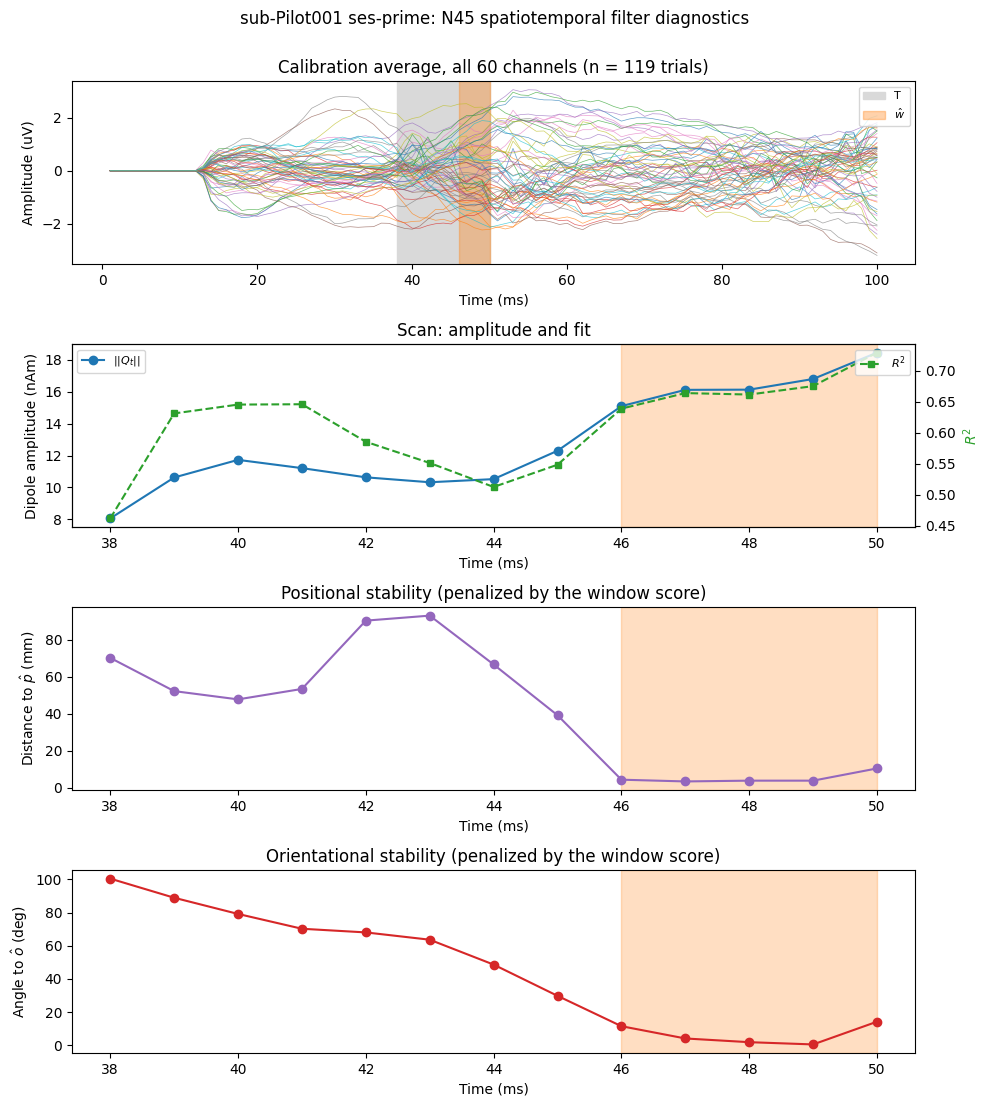

In [29]:
import matplotlib.pyplot as plt

unit_moment = scan['moment'] / np.maximum(
    np.linalg.norm(scan['moment'], axis=1, keepdims=True), 1e-30)
dist_to_phat = np.linalg.norm(scan['pos'] - p_hat, axis=1) * 1000            # mm
angle_to_ohat = np.degrees(np.arccos(np.clip(unit_moment @ o_hat, -1.0, 1.0)))

fig, axes = plt.subplots(4, 1, figsize=(10, 11))

# 1. butterfly over the whole epoch
axes[0].plot(epochs.times * 1000, cal_evoked.data[data_idx].T * 1e6, lw=0.5, alpha=0.7)
axes[0].axvspan(*T_MS, color='0.85', zorder=0, label='T')
axes[0].axvspan(win['start_ms'], win['end_ms'], color='tab:orange', alpha=0.35, zorder=1,
                label='$\\hat{w}$')
axes[0].set(xlabel='Time (ms)', ylabel='Amplitude (uV)',
            title=f'Calibration average, all {n_ch} channels (n = {n_cal} trials)')
axes[0].legend(loc='upper right', fontsize=8)

def _shade(ax):
    ax.axvspan(win['start_ms'], win['end_ms'], color='tab:orange', alpha=0.25, zorder=0)

# 2. amplitude + R^2
axes[1].plot(times_T_ms, scan['amplitude'] * 1e9, 'o-', color='tab:blue', label='$||Q_t||$')
axes[1].set(xlabel='Time (ms)', ylabel='Dipole amplitude (nAm)', title='Scan: amplitude and fit')
ax_r2 = axes[1].twinx()
ax_r2.plot(times_T_ms, scan['r2'], 's--', color='tab:green', ms=4, label='$R^2$')
ax_r2.set_ylabel('$R^2$', color='tab:green')
_shade(axes[1])
axes[1].legend(loc='upper left', fontsize=8)
ax_r2.legend(loc='upper right', fontsize=8)

# 3. positional stability
axes[2].plot(times_T_ms, dist_to_phat, 'o-', color='tab:purple')
axes[2].set(xlabel='Time (ms)', ylabel='Distance to $\\hat{p}$ (mm)',
            title='Positional stability (penalized by the window score)')
_shade(axes[2])

# 4. orientational stability
axes[3].plot(times_T_ms, angle_to_ohat, 'o-', color='tab:red')
axes[3].set(xlabel='Time (ms)', ylabel='Angle to $\\hat{o}$ (deg)',
            title='Orientational stability (penalized by the window score)')
_shade(axes[3])

fig.suptitle(f'sub-{subject} ses-{session}: {COMPONENT} spatiotemporal filter diagnostics',
             y=1.001)
fig.tight_layout()
fig.savefig(out_dir / f'sub-{subject}_ses-{session}_{COMPONENT}_filter_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

Where the filter dipole (built at the end of Section 6) actually sits, on the fsaverage
template. This cell is purely a view -- nothing later depends on it, so it is safe to skip if
there is no working 3D backend.

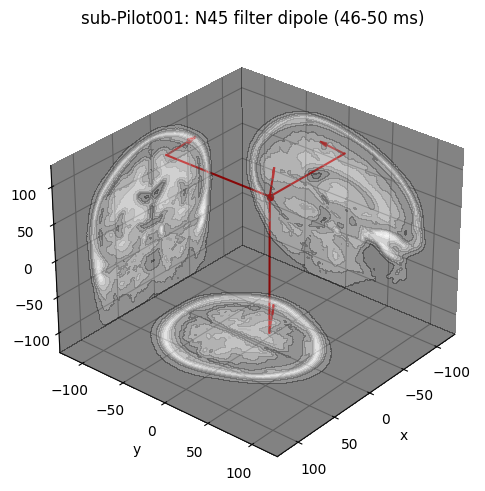

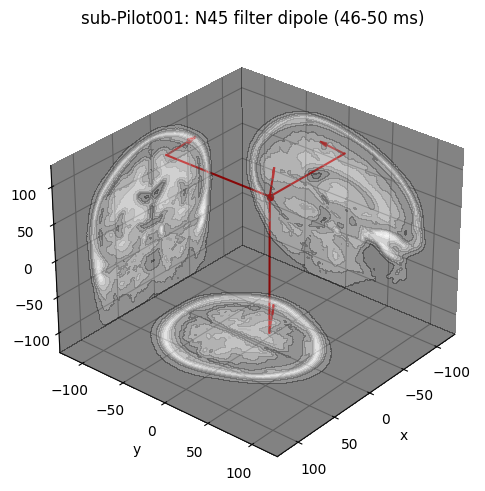

In [30]:
mne.viz.plot_dipole_locations(
    filter_dipole, trans=trans, subject='fsaverage', subjects_dir=subjects_dir,
    title=f"sub-{subject}: {COMPONENT} filter dipole "
          f"({win['start_ms']:.0f}-{win['end_ms']:.0f} ms)")

## 8. [2.5.3] Single-trial amplitude extraction

Apply the finished filter -- fixed `p_hat`, fixed `o_hat`, fixed `w_hat` -- to every trial in
the recording, all blocks and conditions together. Nothing is refit per trial; the only
per-trial freedom is *which sample inside `w_hat`* is used, chosen by maximizing `R^2`.
In the orientation free o is also determined

Both estimators from the source text are computed for every trial:

- **`amp_free_nAm` (PRIMARY)** -- free-orientation, `||Q_i||` where
  `Q_i,t = pinv(L_p_hat) m_i,t`. This is the headline measure, matching prime, whose every
  call site uses `fit_trial(..., orientation='free')`.
- `amp_fixed_nAm` -- fixed-orientation, `|a_i|` where `m_i,t = a_i,t L_p_hat o_hat`. Secondary;
  this is the one the source text treats as primary, kept for comparison.

`amp_fixed_signed_nAm` is kept alongside so polarity reversals stay visible: a trial whose sign
disagrees with the calibration average is one where the topography inverted, and a *high* rate
of those across a block is a warning sign about the filter rather than a finding about the
brain. The saved table is the full per-trial provenance table with these columns appended, so
every amplitude keeps its block, condition, timing and QC information attached.

In [31]:
# (n_trials, n_ch, n_win), channel-centered -- exactly the average reference the leadfield is in
X = epochs.get_data(copy=True)[:, data_idx, :][:, :, win_idx]
X = _center(X, axis=1)

st = extract_amplitudes(X, l_fixed, L_p)
win_times_ms = epochs.times[win_idx] * 1000

single_trial = epochs.metadata.copy().reset_index(drop=True)
single_trial.insert(0, 'trial_index', np.arange(len(single_trial)))
single_trial[f'{COMPONENT}_amp_fixed_nAm'] = st['amp_fixed'] * 1e9
single_trial[f'{COMPONENT}_amp_fixed_signed_nAm'] = st['amp_fixed_signed'] * 1e9
single_trial[f'{COMPONENT}_r2_fixed'] = st['r2_fixed']
single_trial[f'{COMPONENT}_t_fixed_ms'] = win_times_ms[st['t_idx_fixed']]
single_trial[f'{COMPONENT}_amp_free_nAm'] = st['amp_free'] * 1e9
single_trial[f'{COMPONENT}_r2_free'] = st['r2_free']
single_trial[f'{COMPONENT}_t_free_ms'] = win_times_ms[st['t_idx_free']]

st_fname = out_dir / f'sub-{subject}_ses-{session}_desc-{COMPONENT}spatempfilt_singletrial.csv'
single_trial.to_csv(st_fname, index=False)

n_neg = int((st['amp_fixed_signed'] < 0).sum())
print(f"Extracted {len(single_trial)} single-trial {COMPONENT} amplitudes.")
print(f"  free-orientation  : {st['amp_free'].mean()*1e9:7.2f} +/- "
      f"{st['amp_free'].std()*1e9:.2f} nAm   (mean R2 = {st['r2_free'].mean():.3f})   <- PRIMARY (prime default)")
print(f"  fixed-orientation : {st['amp_fixed'].mean()*1e9:7.2f} +/- "
      f"{st['amp_fixed'].std()*1e9:.2f} nAm   (mean R2 = {st['r2_fixed'].mean():.3f})   (secondary)")
print(f"  polarity reversals: {n_neg}/{len(single_trial)} trials "
      f"({100*n_neg/len(single_trial):.1f}%) had a negative signed fixed amplitude")
print(f"\nSaved: {st_fname}")
single_trial.head()

Extracted 756 single-trial N45 amplitudes.
  free-orientation  :   85.08 +/- 40.97 nAm   (mean R2 = 0.474)   <- PRIMARY (prime default)
  fixed-orientation :   47.70 +/- 34.17 nAm   (mean R2 = 0.188)   (secondary)
  polarity reversals: 277/756 trials (36.6%) had a negative signed fixed amplitude

Saved: D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime\sub-Pilot001_ses-prime_desc-N45spatempfilt_singletrial.csv


,trial_index,orig_trial_index,onset,duration,trigger_type_neurone,csv_match,stage,trial_in_stage,iti,trial_start_time,...,block_label,calib_mode,calib_source,N45_amp_fixed_nAm,N45_amp_fixed_signed_nAm,N45_r2_fixed,N45_t_fixed_ms,N45_amp_free_nAm,N45_r2_free,N45_t_free_ms
0,0,1,14.5118,0,A - Stimulation,1,baseline,1,4.257831,2.9800,...,baseline,prime_single,calibration,4.315474,-4.315474,0.003632,46.0,32.778538,0.180414,50.0
1,1,2,19.4832,0,A - Stimulation,1,baseline,2,4.97151,7.2378,...,baseline,prime_single,calibration,28.475020,-28.475020,0.067504,46.0,67.081014,0.448738,47.0
2,2,3,22.8750,0,A - Stimulation,1,baseline,3,3.391781,12.2092,...,baseline,prime_single,calibration,23.966933,23.966933,0.189984,50.0,28.964372,0.257583,50.0
3,3,4,27.4296,0,A - Stimulation,1,baseline,4,4.554699,15.6010,...,baseline,prime_single,calibration,46.777227,46.777227,0.149644,48.0,96.743070,0.682363,46.0
4,4,5,31.3212,0,A - Stimulation,1,baseline,5,3.891652,20.1556,...,baseline,prime_single,calibration,81.936397,81.936397,0.616683,46.0,99.054034,0.781947,47.0


## 9. Per-group TEP amplitudes

The same groups `TEP_dipole_simple.ipynb` compares -- baseline, calibration, each of the four
intervention blocks split into PRIME-triggered vs. PREDETERMINED singles, and every evaluation
timepoint the subject has -- but summarized with this notebook's filter instead of a per-group
dipole fit.

The evaluation timepoints are **discovered from `block_label`** rather than listed, because how
many exist is a per-subject fact: Pilot001 ends at `evaluation-t30`, Pilot002 adds
`evaluation-t60`. The cell prints which ones it found -- check that line against what you
expect for the subject, since a block missing upstream (i.e. never exported by
`organize_neurone.m`, or dropped from `preprocessing_prime.ipynb`'s `TASKS`) will simply not
appear here rather than raise.

Two numbers per group, computed side by side because they answer different questions:

- **`*_evoked_nAm`** -- average the group's trials first, *then* filter. Highest SNR, and it is
  the direct analogue of what the `_simple` notebook reports. Noise averages out before
  rectification, so this is the number to compare across groups. `free_evoked` is the primary
  column (prime's estimator); `fixed_evoked` is kept alongside it.
- **`*_mean_nAm` +/- `*_sem_nAm`** -- filter each trial, *then* average the amplitudes. This is
  the only one of the two that has a variance, so it is what any trial-level statistics have to
  be built on -- but note it is systematically larger than the evoked value, because taking
  `|a_i|` before averaging rectifies noise upward. The gap between the two columns is a rough
  read on per-trial SNR: similar values mean the single trials are informative, a large gap
  means they are mostly noise.

In [33]:
# Positional row indices, guaranteed to line up with X's trial axis.
meta = epochs.metadata.reset_index(drop=True)

groups = [
    ('baseline',    'block_label == "baseline"'),
    ('calibration', 'block_label == "calibration"'),
]
for block_n in [1, 2, 3, 4]:
    block_name = f'intervention_block_{block_n}'
    groups.append((f'{block_name} - prime',
                   f'block_label == "{block_name}" and condition == "prime_single_pulse"'))
    groups.append((f'{block_name} - predetermined',
                   f'block_label == "{block_name}" and condition == "predetermined_single"'))

# Evaluation timepoints are read FROM THE DATA, in recording order, rather than hardcoded.
# How many there are is a per-subject fact -- Pilot001 stops at evaluation-t30, Pilot002 adds
# evaluation-t60 -- and a hardcoded list silently omits any block it does not happen to name,
# which is exactly how t60 would go missing from the group summary without any error.
eval_blocks = [b for b in dict.fromkeys(meta['block_label'].astype(str))
               if b.startswith('evaluation-')]
for tp in eval_blocks:
    groups.append((tp, f'block_label == "{tp}"'))
print(f"Evaluation timepoints found in this dataset: "
      f"{', '.join(eval_blocks) if eval_blocks else '(none)'}")

group_query = dict(groups)

group_rows, group_labels, evoked_stack = [], [], []
for label, query in groups:
    sel = meta.query(query).index.to_numpy()
    if len(sel) < MIN_TRIALS_PER_GROUP:
        print(f"Skipping '{label}': only {len(sel)} trial(s) (< {MIN_TRIALS_PER_GROUP}).")
        continue
    group_labels.append(label)
    evoked_stack.append(X[sel].mean(axis=0))     # average the trials, then filter
    group_rows.append(dict(group=label, n_trials=len(sel), _sel=sel))

ev = extract_amplitudes(np.asarray(evoked_stack), l_fixed, L_p)

records = []
for k, row in enumerate(group_rows):
    sel = row.pop('_sel')
    af, afr = st['amp_fixed'][sel] * 1e9, st['amp_free'][sel] * 1e9
    records.append({
        **row,
        f'{COMPONENT}_fixed_evoked_nAm': ev['amp_fixed'][k] * 1e9,
        f'{COMPONENT}_free_evoked_nAm': ev['amp_free'][k] * 1e9,
        f'{COMPONENT}_r2_fixed_evoked': ev['r2_fixed'][k],
        f'{COMPONENT}_r2_free_evoked': ev['r2_free'][k],
        f'{COMPONENT}_t_fixed_evoked_ms': win_times_ms[ev['t_idx_fixed'][k]],
        f'{COMPONENT}_fixed_mean_nAm': af.mean(),
        f'{COMPONENT}_fixed_sem_nAm': af.std(ddof=1) / np.sqrt(len(af)),
        f'{COMPONENT}_free_mean_nAm': afr.mean(),
        f'{COMPONENT}_free_sem_nAm': afr.std(ddof=1) / np.sqrt(len(afr)),
    })

group_summary = pd.DataFrame(records)
gs_fname = out_dir / f'sub-{subject}_ses-{session}_desc-{COMPONENT}spatempfilt_groupsummary.csv'
group_summary.to_csv(gs_fname, index=False)
print(f"\nSaved: {gs_fname}")
group_summary


Saved: D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime\sub-Pilot001_ses-prime_desc-N45spatempfilt_groupsummary.csv


,group,n_trials,N45_fixed_evoked_nAm,N45_free_evoked_nAm,N45_r2_fixed_evoked,N45_r2_free_evoked,N45_t_fixed_evoked_ms,N45_fixed_mean_nAm,N45_fixed_sem_nAm,N45_free_mean_nAm,N45_free_sem_nAm
0,baseline,94,22.282604,24.906247,0.513319,0.695628,50.0,49.616538,3.313715,88.609739,4.195284
1,calibration,119,18.369234,18.106246,0.696034,0.724991,50.0,49.656700,3.115247,88.797778,3.241450
2,intervention_block_1 - prime,57,14.591523,19.751865,0.466583,0.710403,49.0,41.836423,4.004955,69.732409,4.450204
3,intervention_block_1 - predetermined,19,20.161030,23.553402,0.472350,0.527749,48.0,29.679546,8.845507,66.279585,12.212958
4,intervention_block_2 - prime,50,20.405779,26.244083,0.402970,0.667551,50.0,41.635747,5.008446,77.545576,6.028335
5,intervention_block_2 - predetermined,17,14.280382,33.186704,0.086272,0.352024,50.0,50.040574,9.266691,89.014526,9.463823
6,intervention_block_3 - prime,50,9.198887,9.930740,0.053564,0.078909,49.0,53.454951,4.667527,92.375819,6.294013
7,intervention_block_3 - predetermined,17,7.287594,25.513112,0.039937,0.481677,48.0,42.943974,6.935768,80.609403,8.303154
8,intervention_block_4 - prime,48,12.619897,14.029131,0.410890,0.628386,50.0,36.683933,3.738985,70.586206,4.621625
9,intervention_block_4 - predetermined,19,25.620282,31.140900,0.403306,0.707145,50.0,53.479520,7.944585,90.850645,9.360131


### 9.1 Plots

Two figures. The first is the overview across blocks: group-average-filtered amplitudes on top,
mean +/- SEM of the single-trial amplitudes below, fixed- and free-orientation side by side in
both. The second is the single-trial view -- every trial in recording order, colored by group,
with each group's mean overlaid -- which is what the group bars are hiding, and where drift,
outliers or a block that quietly fell apart will show up.

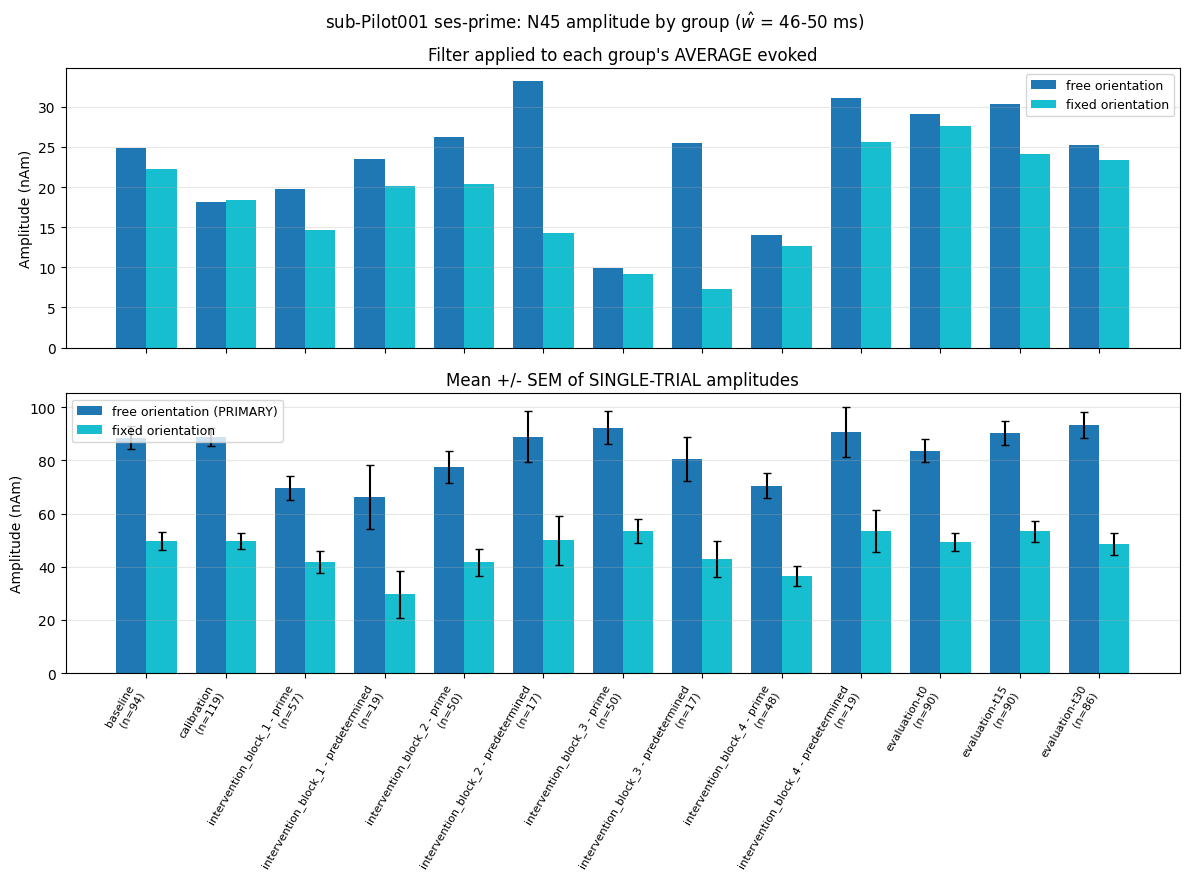

In [37]:
x = np.arange(len(group_summary))
w = 0.38

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].bar(x - w/2, group_summary[f'{COMPONENT}_free_evoked_nAm'], w,
            label='free orientation ', color='tab:blue')
axes[0].bar(x + w/2, group_summary[f'{COMPONENT}_fixed_evoked_nAm'], w,
            label='fixed orientation', color='tab:cyan')
axes[0].set(ylabel='Amplitude (nAm)', title='Filter applied to each group\'s AVERAGE evoked')
axes[0].legend(fontsize=9)

axes[1].bar(x - w/2, group_summary[f'{COMPONENT}_free_mean_nAm'], w,
            yerr=group_summary[f'{COMPONENT}_free_sem_nAm'], capsize=3,
            label='free orientation (PRIMARY)', color='tab:blue')
axes[1].bar(x + w/2, group_summary[f'{COMPONENT}_fixed_mean_nAm'], w,
            yerr=group_summary[f'{COMPONENT}_fixed_sem_nAm'], capsize=3,
            label='fixed orientation', color='tab:cyan')
axes[1].set(ylabel='Amplitude (nAm)',
            title='Mean +/- SEM of SINGLE-TRIAL amplitudes')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xticks(x)
    ax.grid(axis='y', alpha=0.3)
axes[1].set_xticklabels([f"{g}\n(n={n})" for g, n in
                         zip(group_summary['group'], group_summary['n_trials'])],
                        rotation=60, ha='right', fontsize=8)

fig.suptitle(f'sub-{subject} ses-{session}: {COMPONENT} amplitude by group '
             f"($\\hat{{w}}$ = {win['start_ms']:.0f}-{win['end_ms']:.0f} ms)")
fig.tight_layout()
fig.savefig(out_dir / f'sub-{subject}_ses-{session}_{COMPONENT}_amplitude_by_group.png', dpi=150)
plt.show()

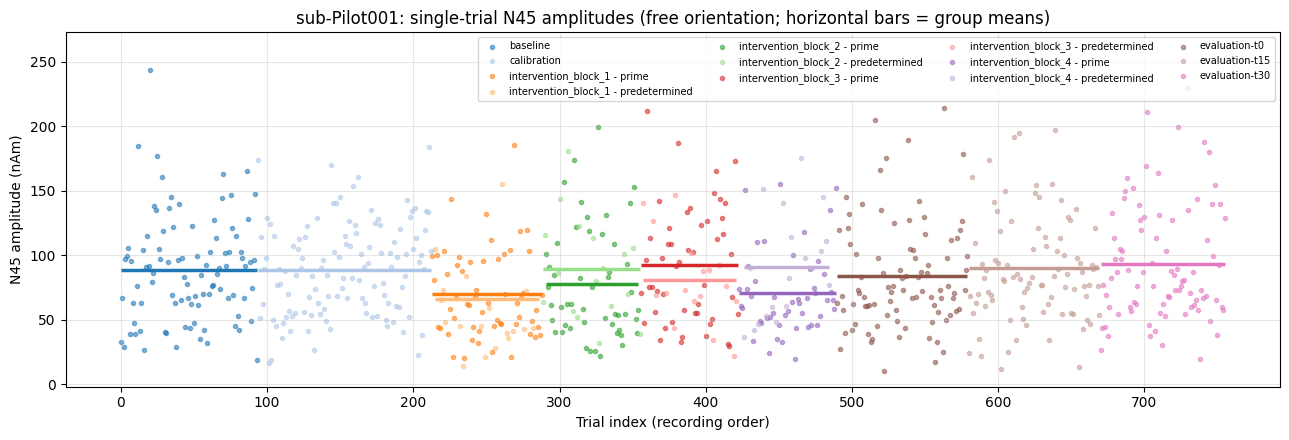

In [38]:
fig, ax = plt.subplots(figsize=(13, 4.5))
cmap = plt.get_cmap('tab20')

amp_all = single_trial[f'{COMPONENT}_amp_free_nAm'].to_numpy()   # PRIMARY estimator
for k, label in enumerate(group_summary['group']):
    sel = meta.query(group_query[label]).index.to_numpy()
    y = amp_all[sel]
    ax.scatter(sel, y, s=9, alpha=0.55, color=cmap(k % 20), label=label)
    ax.hlines(y.mean(), sel.min(), sel.max(), color=cmap(k % 20), lw=2.5)

ax.set(xlabel='Trial index (recording order)', ylabel=f'{COMPONENT} amplitude (nAm)',
       title=f'sub-{subject}: single-trial {COMPONENT} amplitudes '
             '(free orientation; horizontal bars = group means)')
ax.legend(fontsize=7, ncol=4, loc='upper right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f'sub-{subject}_ses-{session}_{COMPONENT}_singletrial_timeline.png', dpi=150)
plt.show()

## 10. Save the filter definition

The filter is the reusable object here: given `p_hat`, `o_hat` and `w_hat`, any other recording
from this subject can be scored without redoing Sections 5-6. Three files:

- `*_filter.json` -- everything needed to rebuild the filter, plus the parameters and the
  data provenance it was derived from, so a saved amplitude can always be traced back to the
  exact filter that produced it.
- `*_dipole.dip` -- the same dipole as an `mne.Dipole`, for re-plotting in MNE directly via
  `mne.read_dipole`. Note the extension: `mne.Dipole` saves through `.save()` to a `.dip` /
  `.bdip` file, and there is no `mne.write_dipole` in current MNE -- `TEP_dipole_simple.ipynb`
  calls `mne.write_dipole(..., '.fif')`, which does not work on MNE >= 1.x and is worth fixing
  there separately.
- `*_scan.csv` -- the full per-time-point scan over `T`, for re-examining the window choice
  without re-running the (slow) forward solution.

In [36]:
import json

filter_def = dict(
    subject=subject, session=session, component=COMPONENT,
    # --- the filter itself ---
    p_hat_m=p_hat.tolist(), o_hat=o_hat.tolist(),
    window_ms=[win['start_ms'], win['end_ms']], window_n_samples=int(win['n_samples']),
    source_index=(int(p_idx) if p_idx is not None else None),
    l_fixed=l_fixed.tolist(), ch_names=ch_used,
    # --- how it was derived ---
    target_interval_ms=list(T_MS), window_size_samples=list(WINDOW_SIZE_SAMPLES), alpha=ALPHA,
    resample_method=RESAMPLE_METHOD,
    post_initial_ms=list(POST_INITIAL_MS), post_ms=list(POST_MS),
    amplitude_stat=AMPLITUDE_STAT, position_mode=POSITION_MODE,
    calibration_query=CALIBRATION_QUERY, n_calibration_trials=int(n_cal),
    sfreq_hz=float(sfreq), sfreq_native_hz=float(sfreq_native),
    src_spacing=SRC_SPACING, n_sources=int(n_src), montage=MONTAGE, mindist_mm=MINDIST_MM,
    # --- quality of the fit ---
    window_score=win['score'], window_pos_dev_mm=win['pos_dev_mm'],
    window_ang_dev_deg=win['ang_dev_deg'], snap_distance_mm=snap_mm,
    mean_r2_in_window=float(scan['r2'][i0:i1 + 1].mean()),
    n_distinct_sources_in_T=int(n_distinct),
)

filter_fname = out_dir / f'sub-{subject}_ses-{session}_desc-{COMPONENT}spatempfilt_filter.json'
with open(filter_fname, 'w') as fh:
    json.dump(filter_def, fh, indent=2)

dipole_fname = out_dir / f'sub-{subject}_ses-{session}_desc-{COMPONENT}spatempfilt_dipole.dip'
filter_dipole.save(dipole_fname, overwrite=True)   # read back with mne.read_dipole()

scan_fname = out_dir / f'sub-{subject}_ses-{session}_desc-{COMPONENT}spatempfilt_scan.csv'
pd.DataFrame(dict(
    time_ms=times_T_ms, src_idx=scan['src_idx'],
    pos_x_mm=scan['pos'][:, 0]*1000, pos_y_mm=scan['pos'][:, 1]*1000,
    pos_z_mm=scan['pos'][:, 2]*1000,
    q_x=scan['moment'][:, 0], q_y=scan['moment'][:, 1], q_z=scan['moment'][:, 2],
    amplitude_nAm=scan['amplitude']*1e9, r2=scan['r2'],
    dist_to_p_hat_mm=dist_to_phat, angle_to_o_hat_deg=angle_to_ohat,
    in_window=[(i0 <= k <= i1) for k in range(len(times_T_ms))],
)).to_csv(scan_fname, index=False)

print("Saved:")
for f in (filter_fname, dipole_fname, scan_fname, st_fname, gs_fname):
    print(f"  {f}")
print("\nDone.")

Overwriting existing file.
Saved:
  D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime\sub-Pilot001_ses-prime_desc-N45spatempfilt_filter.json
  D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime\sub-Pilot001_ses-prime_desc-N45spatempfilt_dipole.dip
  D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime\sub-Pilot001_ses-prime_desc-N45spatempfilt_scan.csv
  D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime\sub-Pilot001_ses-prime_desc-N45spatempfilt_singletrial.csv
  D:\Linus\Loop\BIDS\derivatives\sub-Pilot001\ses-prime\sub-Pilot001_ses-prime_desc-N45spatempfilt_groupsummary.csv

Done.
